In [1]:
from notebook_setup import setup_notebook_environment

PROJECT_ROOT, SIMULATION_PATH = setup_notebook_environment()

In [2]:
#get the list of all the compartment names

import src.signal_models as sm

exclude = {'Standard_WM','t1_smdt'}

compartments = [c for c in sm.__all__ if c not in exclude]
compartments


['Ball',
 'Msdki',
 'Zeppelin',
 'Ballt2',
 'Sphere',
 'Stick',
 'Cylinder',
 'Astrosticks']

In [3]:
import matplotlib.pyplot as plt

from src.model_maker import ModelMaker

modelfunc = {}

for compartment in compartments:            
    
    modelfunc[compartment] = ModelMaker(compartment)

    

-----------
########### Making model:  Ball
########### Compartments: [<src.signal_models.gaussian_models.Ball object at 0x116b2ecc0>]
########### Parameter names: [['D']]
########### Parameter ranges: [[[0.001, 3]]]
-----------
-----------
########### Making model:  Msdki
########### Compartments: [<src.signal_models.gaussian_models.Msdki object at 0x116b2eb40>]
########### Parameter names: [['D', 'K']]
########### Parameter ranges: [[[0.001, 3], [0.001, 2]]]
-----------
-----------
########### Making model:  Zeppelin
########### Compartments: [<src.signal_models.gaussian_models.Zeppelin object at 0x116b2e810>]
########### Parameter names: [['Dpar', 'k', 'theta', 'phi']]
########### Parameter ranges: [[[0.001, 3], [0.001, 1.0], [0, 3.141592653589793], [-3.141592653589793, 3.141592653589793]]]
-----------
-----------
########### Making model:  Ballt2
########### Compartments: [<src.signal_models.gaussian_models.Ballt2 object at 0x116b2eb70>]
########### Parameter names: [['D', 'T2']]
#

In [4]:
from src.utils.acquisition_scheme import acquisition_scheme_loader
import os

grad = acquisition_scheme_loader(os.path.join(SIMULATION_PATH,"grad","grad_HCP_with_deltas.txt"))

grad = acquisition_scheme_loader(os.path.join(SIMULATION_PATH,"grad","grad_ivim_T2.txt"))

Assumed b-values are given in s/mm^2 and converted to ms/μm^2 for internal use. If this is not correct, please check your b-values and ensure they are in the correct units.
Assumed TE values are given in ms and converted to seconds for internal use. If this is not correct, please check your TE values and ensure they are in the correct units.


In [ ]:
import torch
import matplotlib.pyplot as plt 
from src.utils.make_test_image import generate_random_params

S = {}
n_samples = 5

for compartment in compartments:
    #randomly sample a parameter set from the parameter space of the model.
    params = generate_random_params(modelfunc[compartment], n_samples)

    S[compartment] = modelfunc[compartment](grad, params).unsqueeze(0)




tensor([2.0200e-07, 2.0200e-07, 2.0200e-07, 2.8568e-05, 2.8568e-05, 2.8568e-05,
        4.5169e-05, 4.5169e-05, 4.5169e-05, 5.5321e-05, 5.5321e-05, 5.5321e-05,
        6.3879e-05, 6.3879e-05, 6.3879e-05, 7.8236e-05, 7.8236e-05, 7.8236e-05,
        9.0339e-05, 9.0339e-05, 9.0339e-05, 1.1064e-04, 1.1064e-04, 1.1064e-04,
        1.2776e-04, 1.2776e-04, 1.2776e-04, 1.4284e-04, 1.4284e-04, 1.4284e-04,
        1.5647e-04, 1.5647e-04, 1.5647e-04, 1.8068e-04, 1.8068e-04, 1.8068e-04,
        2.0200e-04, 2.0200e-04, 2.0200e-04, 2.2128e-04, 2.2128e-04, 2.2128e-04,
        2.5552e-04, 2.5552e-04, 2.5552e-04, 2.0200e-07, 2.0200e-07, 2.0200e-07,
        2.8568e-05, 2.8568e-05, 2.8568e-05, 4.5169e-05, 4.5169e-05, 4.5169e-05,
        5.5321e-05, 5.5321e-05, 5.5321e-05, 6.3879e-05, 6.3879e-05, 6.3879e-05,
        7.8236e-05, 7.8236e-05, 7.8236e-05, 9.0339e-05, 9.0339e-05, 9.0339e-05,
        1.1064e-04, 1.1064e-04, 1.1064e-04, 1.2776e-04, 1.2776e-04, 1.2776e-04,
        1.4284e-04, 1.4284e-04, 1.4284e-

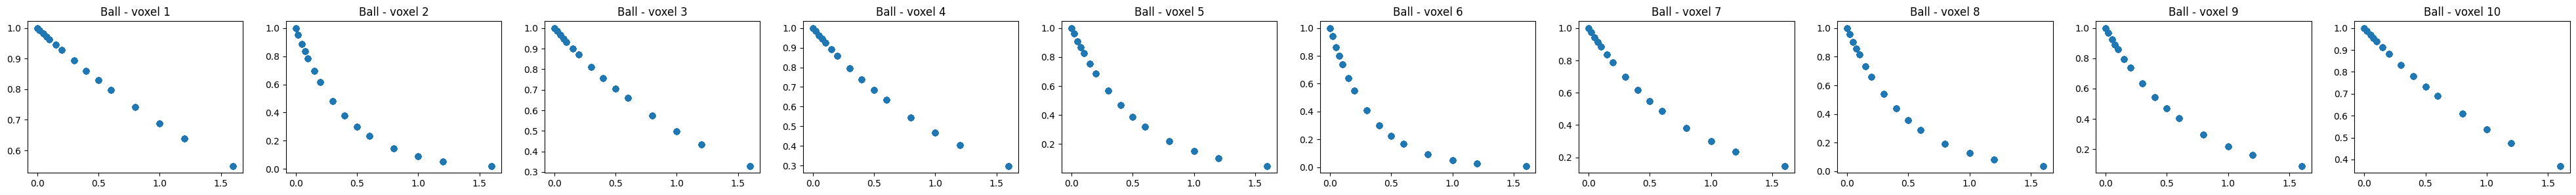

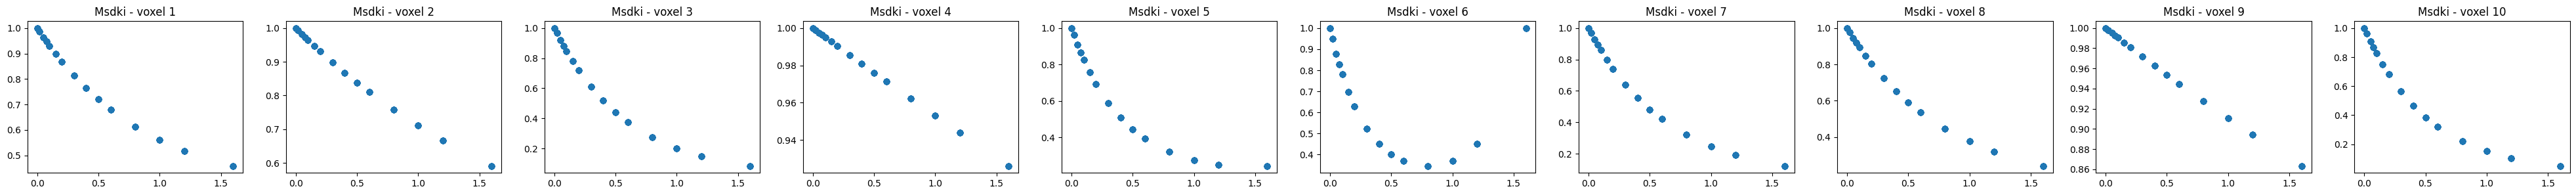

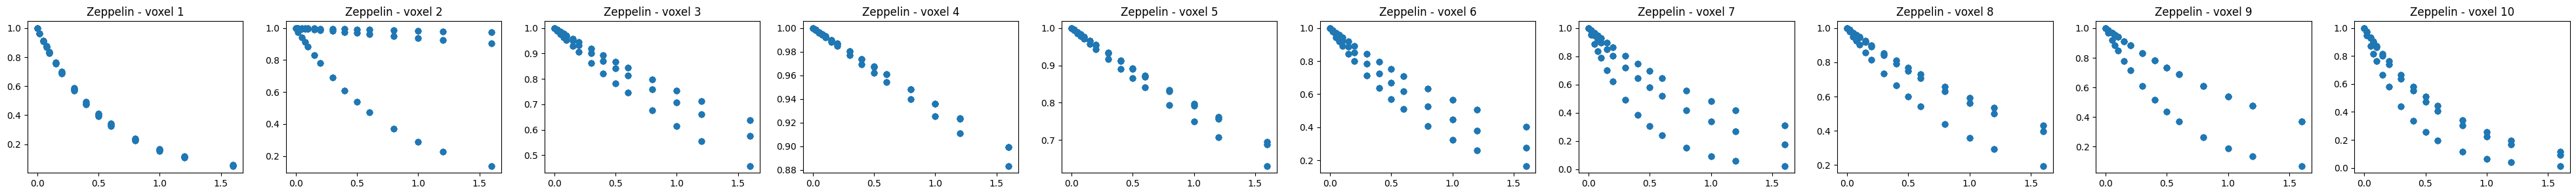

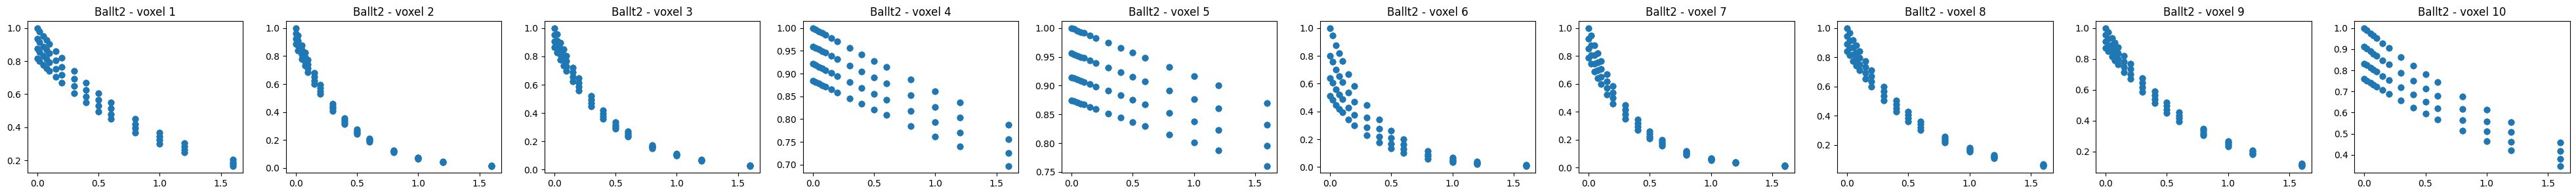

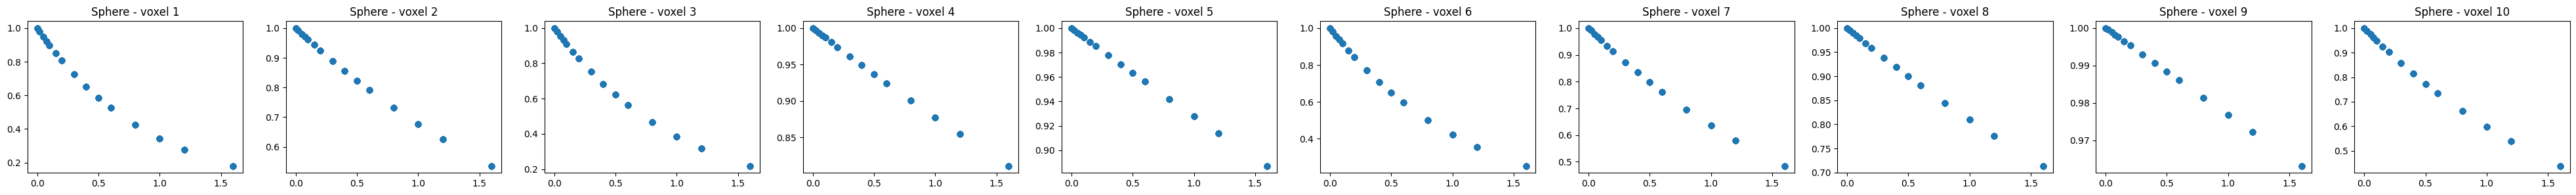

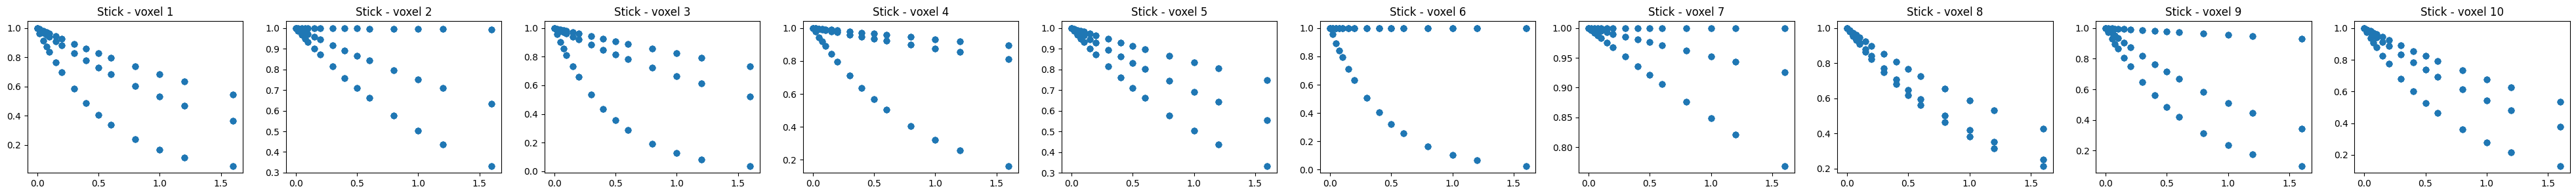

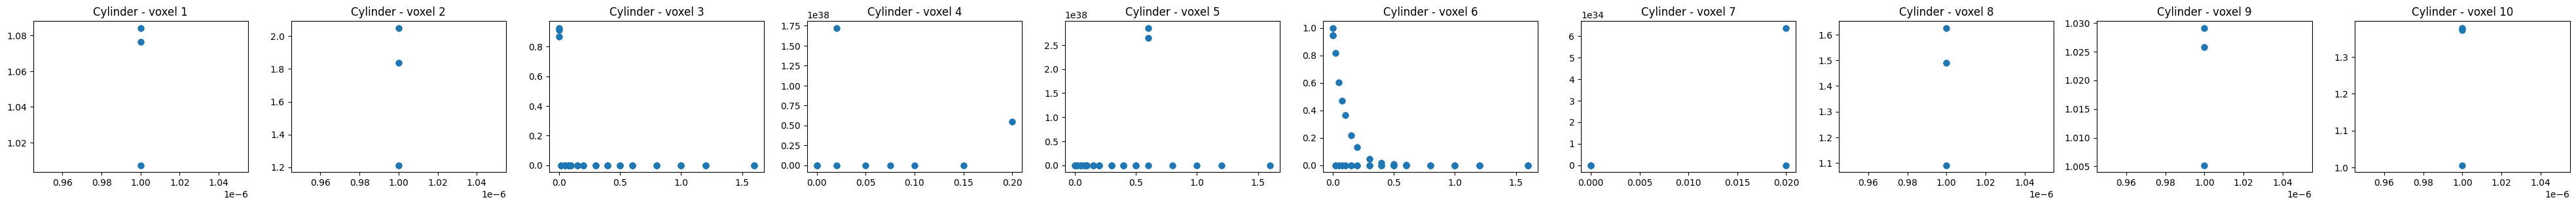

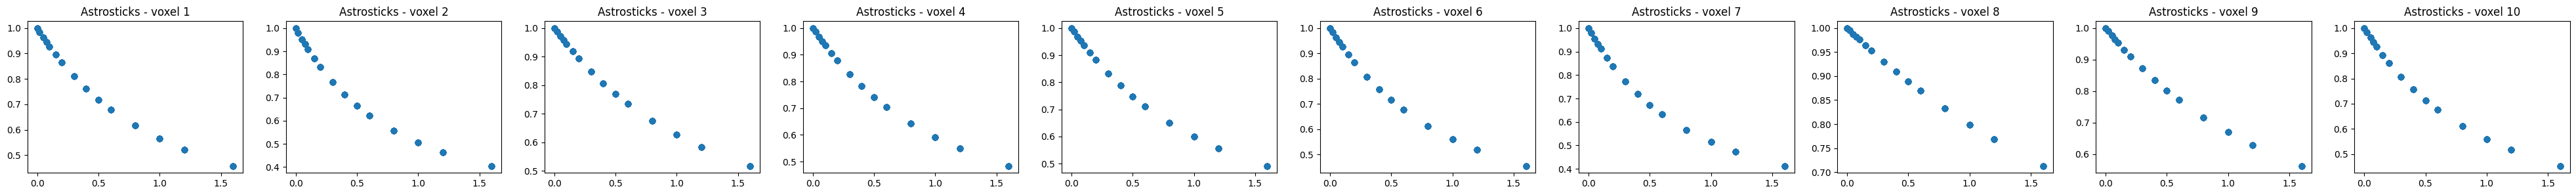

In [6]:
for compartment in compartments:
    n_voxels = S[compartment].shape[1]
    _, ax = plt.subplots(1, n_voxels, figsize=(5 * n_voxels, 3))
    for i in range(n_voxels):
        ax[i].plot(grad.bvalues, S[compartment][0,i,:],'o')
        ax[i].set_title(f"{compartment} - voxel {i+1}")